In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
np.random.seed(42)
n_rows = 500

# E-commerce dataset ka sample data
data = {
    'Order_ID': [f'ORD_{1000+i}' for i in range(n_rows)],
    'Customer_ID': [f'CUST_{np.random.randint(101, 150)}' for i in range(n_rows)],
    'Order_Date': pd.date_range(start='2023-01-01', periods=n_rows, freq='D'),
    'Category': np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Books'], size=n_rows, p=[0.3, 0.3, 0.2, 0.2]),
    'Sales_Amount': np.random.normal(loc=150, scale=50, size=n_rows).round(2),
    'Quantity': np.random.randint(1, 6, size=n_rows),
    'Payment_Method': np.random.choice(['Credit Card', 'UPI', 'Debit Card', 'Net Banking'], size=n_rows)
}

df = pd.DataFrame(data)

# Real-world data touch dene ke liye 5-6 missing values add karte hain
df.loc[10:15, 'Sales_Amount'] = np.nan

# CSV file save kar rahe hain folder mein
df.to_csv('ecommerce_data.csv', index=False)

# Pehle 5 rows screen par dekhne ke liye
df.head()

,Order_ID,Customer_ID,Order_Date,Category,Sales_Amount,Quantity,Payment_Method
0,ORD_1000,CUST_139,2023-01-01,Home & Kitchen,263.83,5,Debit Card
1,ORD_1001,CUST_129,2023-01-02,Electronics,68.53,1,Credit Card
2,ORD_1002,CUST_115,2023-01-03,Books,155.49,4,UPI
3,ORD_1003,CUST_143,2023-01-04,Books,206.48,2,Debit Card
4,ORD_1004,CUST_108,2023-01-05,Electronics,121.08,5,Net Banking


In [5]:
# 1. Dataset ka shape (rows aur columns ki ginti)
print("Dataset Shape:", df.shape)

# 2. Columns ke data types aur missing values ki info
print("\n--- Data Info ---")
df.info()

# 3. Numeric columns ka basic summary statistics
print("\n--- Summary Statistics ---")
df.describe()

Dataset Shape: (500, 7)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        500 non-null    str           
 1   Customer_ID     500 non-null    str           
 2   Order_Date      500 non-null    datetime64[us]
 3   Category        500 non-null    str           
 4   Sales_Amount    494 non-null    float64       
 5   Quantity        500 non-null    int32         
 6   Payment_Method  500 non-null    str           
dtypes: datetime64[us](1), float64(1), int32(1), str(4)
memory usage: 25.5 KB

--- Summary Statistics ---


,Order_Date,Sales_Amount,Quantity
count,500,494.000000,500.000000
mean,2023-09-07 12:00:00,152.674190,3.092000
min,2023-01-01 00:00:00,-28.410000,1.000000
25%,2023-05-05 18:00:00,121.705000,2.000000
50%,2023-09-07 12:00:00,153.130000,3.000000
75%,2024-01-10 06:00:00,188.267500,4.000000
max,2024-05-14 00:00:00,304.700000,5.000000
std,NaN,51.427957,1.428151


In [6]:
# 1. Check missing values count per column
print("Missing values per column:")
print(df.isnull().sum())

# 2. Sales_Amount mein jo 6 missing values hain unhe Mean (Average) se fill karte hain
mean_sales = df['Sales_Amount'].mean()
df['Sales_Amount'].fillna(mean_sales, inplace=True)

print("\nMissing values after filling:")
print(df.isnull().sum())

Missing values per column:
Order_ID          0
Customer_ID       0
Order_Date        0
Category          0
Sales_Amount      6
Quantity          0
Payment_Method    0
dtype: int64

Missing values after filling:
Order_ID          0
Customer_ID       0
Order_Date        0
Category          0
Sales_Amount      6
Quantity          0
Payment_Method    0
dtype: int64


C:\Users\Kulwinder kanwar\AppData\Local\Temp\ipykernel_12904\3567576195.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Sales_Amount'].fillna(mean_sales, inplace=True)


In [7]:
# 1. Total Sales by Category
category_sales = df.groupby('Category')['Sales_Amount'].sum().reset_index()
category_sales = category_sales.sort_values(by='Sales_Amount', ascending=False)

print("--- Total Sales by Category ---")
print(category_sales)

# 2. Most Popular Payment Method (Count of Orders)
payment_counts = df['Payment_Method'].value_counts()

print("\n--- Orders Count by Payment Method ---")
print(payment_counts)

--- Total Sales by Category ---
         Category  Sales_Amount
1        Clothing      25729.75
2     Electronics      20749.28
3  Home & Kitchen      14788.17
0           Books      14153.85

--- Orders Count by Payment Method ---
Payment_Method
Net Banking    140
UPI            130
Credit Card    117
Debit Card     113
Name: count, dtype: int64


In [8]:
# 1. Total Sales by Category
category_sales = df.groupby('Category')['Sales_Amount'].sum().reset_index()
category_sales = category_sales.sort_values(by='Sales_Amount', ascending=False)

print("--- Total Sales by Category ---")
print(category_sales)

# 2. Most Popular Payment Method (Count of Orders)
payment_counts = df['Payment_Method'].value_counts()

print("\n--- Orders Count by Payment Method ---")
print(payment_counts)

--- Total Sales by Category ---
         Category  Sales_Amount
1        Clothing      25729.75
2     Electronics      20749.28
3  Home & Kitchen      14788.17
0           Books      14153.85

--- Orders Count by Payment Method ---
Payment_Method
Net Banking    140
UPI            130
Credit Card    117
Debit Card     113
Name: count, dtype: int64


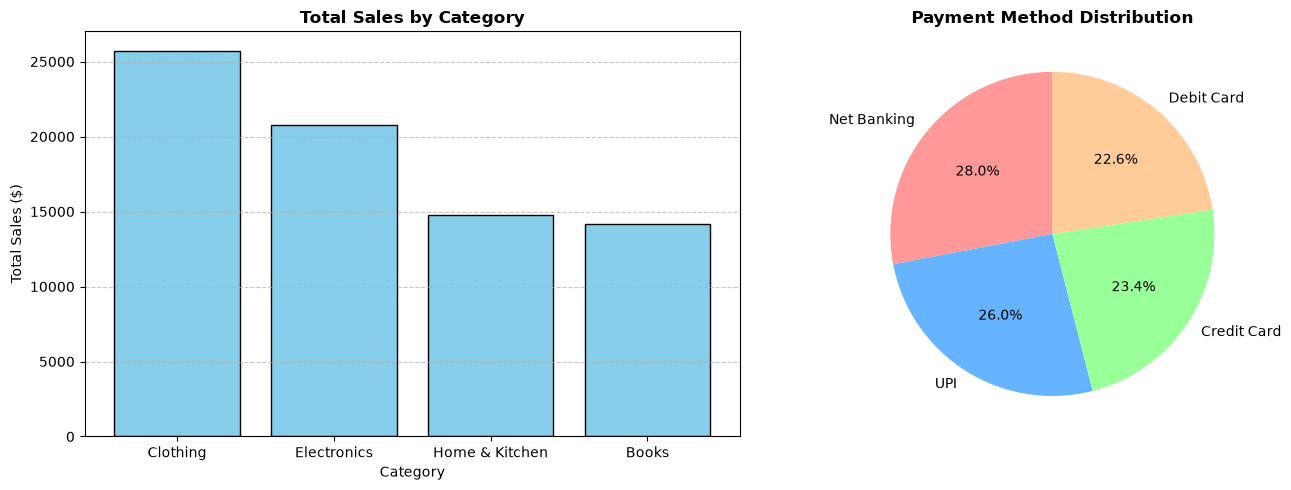

In [10]:
# Canvas setup for 2 charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Bar Chart for Category Sales
axes[0].bar(category_sales['Category'], category_sales['Sales_Amount'], color='skyblue', edgecolor='black')
axes[0].set_title('Total Sales by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Chart 2: Pie Chart for Payment Methods
axes[1].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1].set_title('Payment Method Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()